# Build and evaluate point-in-time graph features

**Goal.** Build graph features using only relationships known at payment time, evaluate a small temporal baseline, and optionally convert the graph to PyTorch Geometric.

**Prerequisites.** Base FraudTwin install. Optional extras and Docker commands are clearly marked.

**Produces.** A readable graph summary, a temporal feature table, one diagnostic plot, and hold-out metrics.


**Source size.** The graph fixture generates fewer than 1,000 payments and includes known graph campaigns so the temporal hold-out has labels.

**Offline path.** All marked offline cells run without Docker or network services. Service cells are optional and explicitly marked in notebook metadata.

**Important.** The fraud labels below are simulator truth used only for the offline demonstration. In production, replace them with labels that have reached your declared maturity policy.


In [1]:
!pip install torch-geometric matplotlib


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


**Set up a deterministic source run**


In [2]:
import json
from pathlib import Path

import polars as pl

from fraudtwin.config import load_config
from fraudtwin.generation import generate

root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "configs" / "minimal.yaml").exists()),
    Path.cwd(),
)
config = load_config(root / "configs" / "benchmarks" / "graph-v2.yaml")
data = generate(config, write=False)
run_id = data.run_id
payments = pl.DataFrame([item.model_dump(mode="json") for item in data.behavior.payments])
print("Source run")
print(f"  run_id: {run_id}")
print(f"  payments: {len(payments):,}")
print(f"  payment events: {len(data.behavior.payment_events):,}")
print(f"  graph campaigns: {len(data.behavior.graph_campaigns):,}")

Source run
  run_id: RUN-d4fe1230e312957d
  payments: 757
  payment events: 2,642
  graph campaigns: 13


**Inspect the graph**

The observable view contains nodes and relationships available to a downstream detector. The table below is a compact count by relationship type.


In [3]:
from fraudtwin.graph import build_graph, validate_graph

graph = build_graph(config, data.entities, data.behavior, data.manifest, view="observable")
validate_graph(graph)
nodes, edges = graph.node_frame, graph.edge_frame
print("Observable graph")
print(f"  nodes: {nodes.height:,}")
print(f"  edges: {edges.height:,}")
display(
    edges.group_by("edge_type")
    .len()
    .rename({"len": "edges"})
    .sort("edges", descending=True)
    .head(8)
)

Observable graph
  nodes: 417
  edges: 4,191


edge_type,edges
str,u32
"""USES""",960
"""SHARES_DEVICE""",680
"""TRANSFERRED_TO""",625
"""PAID""",526
"""PURCHASED_FROM""",526
"""RECEIVED_FROM""",488
"""OWNS""",240
"""HELD_AT""",120


**Build point-in-time features**

For every payment, count only incident event edges whose event time and availability are earlier than the payment. This is the leakage-safe feature boundary we will evaluate.


In [4]:
from datetime import timedelta

# Use only event edges observed strictly before each payment.
edge_rows = edges.to_dicts()
truth_ids = {record.payment_id for record in data.behavior.fraud_records if record.fraud_truth}
holdout_at = data.manifest.start_time + timedelta(minutes=40)
feature_rows = []
for payment in data.behavior.payments:
    prior_edges = [
        edge
        for edge in edge_rows
        if edge["event_time"] is not None
        and edge["event_time"] < payment.initiated_at
        and (edge["available_at"] is None or edge["available_at"] <= payment.initiated_at)
        and (edge["valid_to"] is None or payment.initiated_at <= edge["valid_to"])
        and (
            edge["src_id"] == payment.payer_account_id or edge["dst_id"] == payment.payer_account_id
        )
    ]
    counterparties = {
        edge["dst_id"] if edge["src_id"] == payment.payer_account_id else edge["src_id"]
        for edge in prior_edges
    }
    feature_rows.append(
        {
            "payment_id": payment.payment_id,
            "initiated_at": payment.initiated_at,
            "prior_event_edges": len(prior_edges),
            "prior_counterparties": len(counterparties),
            "label": int(payment.payment_id in truth_ids),
            "split": "train" if payment.initiated_at < holdout_at else "test",
        }
    )
features = pl.DataFrame(feature_rows).sort("initiated_at")
print("Point-in-time features")
print(f"  rows: {features.height:,}")
print("  features: prior_event_edges, prior_counterparties")
print(f"  hold-out starts: {holdout_at.isoformat()}")
display(features.head(8))

Point-in-time features
  rows: 757
  features: prior_event_edges, prior_counterparties
  hold-out starts: 2026-01-01T00:40:00+00:00


payment_id,initiated_at,prior_event_edges,prior_counterparties,label,split
str,"datetime[μs, UTC]",i64,i64,i64,str
"""PAY-G-MERCHANT_CUSTOMER_COMMUN…",2026-01-01 00:05:00 UTC,0,0,1,"""train"""
"""PAY-00000457""",2026-01-01 00:06:00 UTC,0,0,0,"""train"""
"""PAY-G-DENSE_CAMPAIGN-0011-0000…",2026-01-01 00:10:00 UTC,0,0,1,"""train"""
"""PAY-G-MERCHANT_CUSTOMER_COMMUN…",2026-01-01 00:10:00 UTC,0,0,1,"""train"""
"""PAY-G-MULE_NETWORK-0001-00001""",2026-01-01 00:15:00 UTC,0,0,1,"""train"""
"""PAY-G-CYCLIC_RING-0002-00001""",2026-01-01 00:15:00 UTC,0,0,1,"""train"""
"""PAY-G-BIPARTITE_NETWORK-0005-0…",2026-01-01 00:15:00 UTC,0,0,1,"""train"""
"""PAY-G-STACKED_NETWORK-0006-000…",2026-01-01 00:15:00 UTC,0,0,1,"""train"""


**Check the optional PyG representation**

PyTorch Geometric is an optional adapter. It changes the representation of the graph; it does not train or evaluate a model by itself.


In [5]:
try:
    from fraudtwin.graph import to_pyg

    pyg = to_pyg(graph)
    print(f"PyG conversion succeeded: {type(pyg).__name__}")
    print(f"  node types: {len(pyg.node_types)}")
    print(f"  edge types: {len(pyg.edge_types)}")
except (ImportError, RuntimeError):
    pyg = None
    print("PyTorch Geometric is optional; using tabular degree features.")

PyTorch Geometric is optional; using tabular degree features.


**Visualize the temporal feature signal**

The plot shows prior graph activity at payment time and marks the chronological hold-out boundary. Simulator truth is used only to color the diagnostic points.


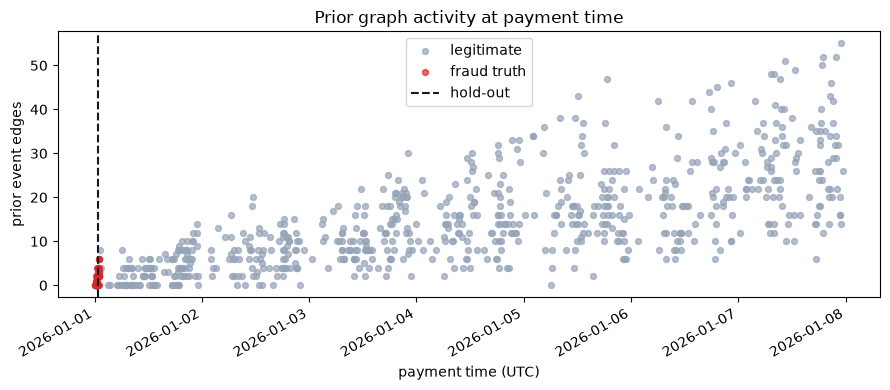

payment_id,prior_event_edges,prior_counterparties,split
str,i64,i64,str
"""PAY-G-MERCHANT_CUSTOMER_COMMUN…",0,0,"""train"""
"""PAY-00000457""",0,0,"""train"""
"""PAY-G-DENSE_CAMPAIGN-0011-0000…",0,0,"""train"""
"""PAY-G-MERCHANT_CUSTOMER_COMMUN…",0,0,"""train"""
"""PAY-G-MULE_NETWORK-0001-00001""",0,0,"""train"""
"""PAY-G-CYCLIC_RING-0002-00001""",0,0,"""train"""
"""PAY-G-BIPARTITE_NETWORK-0005-0…",0,0,"""train"""
"""PAY-G-STACKED_NETWORK-0006-000…",0,0,"""train"""


In [6]:
try:
    import matplotlib.pyplot as plt

    fig, axis = plt.subplots(figsize=(9, 4))
    for label, name, color in ((0, "legitimate", "#94a3b8"), (1, "fraud truth", "#dc2626")):
        points = features.filter(pl.col("label") == label)
        axis.scatter(
            points["initiated_at"].to_list(),
            points["prior_event_edges"].to_list(),
            s=18,
            alpha=0.7,
            label=name,
            color=color,
        )
    axis.axvline(holdout_at, color="#111827", linestyle="--", label="hold-out")
    axis.set(
        title="Prior graph activity at payment time",
        xlabel="payment time (UTC)",
        ylabel="prior event edges",
    )
    axis.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()
    plt.close(fig)
except ImportError:
    print("Install matplotlib to render the graph feature plot.")

display(
    features.select(["payment_id", "prior_event_edges", "prior_counterparties", "split"]).head(8)
)

**Evaluate the temporal baseline**

This is a deliberately small structural baseline, not a trained GNN. The metrics confirm that the feature table, label alignment, and chronological split are all real before a more complex graph model is introduced.


In [7]:
from sklearn.metrics import average_precision_score, roc_auc_score

from fraudtwin.reproducibility import sha256_json

train = features.filter(pl.col("split") == "train")
test = features.filter(pl.col("split") == "test")
test_labels = test["label"].to_numpy()
# This deliberately simple score is a baseline, not a trained GNN.
graph_scores = test["prior_event_edges"].to_numpy()
metrics = {
    "baseline": "prior event degree",
    "train_rows": train.height,
    "test_rows": test.height,
    "test_positive_labels": int(test["label"].sum()),
    "roc_auc": round(float(roc_auc_score(test_labels, graph_scores)), 3),
    "pr_auc": round(float(average_precision_score(test_labels, graph_scores)), 3),
}
print("Temporal baseline")
for name, value in metrics.items():
    print(f"  {name}: {value}")
print(f"  feature fingerprint: {sha256_json(features.to_dicts())[:12]}...")

Temporal baseline
  baseline: prior event degree
  train_rows: 28
  test_rows: 729
  test_positive_labels: 28
  roc_auc: 0.098
  pr_auc: 0.027
  feature fingerprint: ef858278a7c7...


**Verify the temporal boundary**

These assertions make the important tutorial claim executable: training rows precede test rows, and the test window contains both labels.


In [8]:
assert graph.output_fingerprint
assert train["initiated_at"].max() < test["initiated_at"].min()
assert test["label"].n_unique() == 2
print("Verified: features use only earlier available event edges.")
print("Verified: the test window contains both labels.")

Verified: features use only earlier available event edges.
Verified: the test window contains both labels.


**Inspect a few source rows**


In [9]:
# A compact inspection is more useful than printing an entire run.
sample_columns = [
    c for c in ("payment_id", "amount", "initiated_at", "payer_account_id") if c in payments.columns
]
sample_rows = payments.select(sample_columns).head(8).to_dicts()
print(f"Sample payments ({len(sample_rows)} of {payments.height} rows):")
for row in sample_rows:
    print(
        f"  - {row.get('payment_id')}: amount={row.get('amount')}, "
        f"initiated_at={row.get('initiated_at')}, payer={row.get('payer_account_id')}"
    )
nulls = {name: count for name, count in payments.null_count().to_dicts()[0].items() if count}
print("\nData quality summary:")
print(f"  rows: {payments.height}")
print(f"  columns: {payments.width}")
if not nulls:
    print("  nulls: none")
else:
    print("  columns with nulls:")
    for name, count in sorted(nulls.items()):
        print(f"    - {name}: {count}")

Sample payments (8 of 757 rows):
  - PAY-00000001: amount=16.48, initiated_at=2026-01-03T22:42:00Z, payer=ACC-000028
  - PAY-00000002: amount=50.72, initiated_at=2026-01-02T21:42:00Z, payer=ACC-000104
  - PAY-00000003: amount=10.0, initiated_at=2026-01-01T13:14:00Z, payer=ACC-000055
  - PAY-00000004: amount=393.98, initiated_at=2026-01-06T14:22:00Z, payer=ACC-000088
  - PAY-00000005: amount=14.33, initiated_at=2026-01-05T13:22:00Z, payer=ACC-000042
  - PAY-00000006: amount=10.0, initiated_at=2026-01-05T18:51:00Z, payer=ACC-000055
  - PAY-00000007: amount=19.03, initiated_at=2026-01-07T18:14:00Z, payer=ACC-000099
  - PAY-00000008: amount=20.44, initiated_at=2026-01-05T12:47:00Z, payer=ACC-000080

Data quality summary:
  rows: 757
  columns: 15
  columns with nulls:
    - card_id: 500
    - merchant_id: 488
    - payee_account_id: 12
    - payee_pix_key_id: 620
    - payer_pix_key_id: 620


**Review the run manifest**


In [10]:
summary = {
    "run_id": run_id,
    "payments": len(data.behavior.payments),
    "payment_events": len(data.behavior.payment_events),
    "graph_campaigns": len(data.behavior.graph_campaigns),
    "fraud_records": len(data.behavior.fraud_records),
}
assert summary["payments"] == len(payments)
assert summary["payments"] > 0
print(json.dumps(summary, indent=2, default=str))

{
  "run_id": "RUN-d4fe1230e312957d",
  "payments": 757,
  "payment_events": 2642,
  "graph_campaigns": 13,
  "fraud_records": 57
}


**Optional next step: convert to PyG**

Install the optional extra and rerun the final cell to inspect the typed PyG representation. A real GNN should be added only after establishing a stronger baseline and a production label policy.


In [11]:
try:
    from fraudtwin.graph import to_pyg

    pyg_data = to_pyg(graph)
    print(
        {
            "converted": True,
            "num_nodes": int(pyg_data.num_nodes),
            "node_types": len(pyg_data.node_types),
            "edge_types": len(pyg_data.edge_types),
        }
    )
except Exception as exc:
    print({"converted": False, "offline_fallback": True, "reason": type(exc).__name__})

{'converted': False, 'offline_fallback': True, 'reason': 'RuntimeError'}


In [12]:
assert graph.output_fingerprint
print({"offline_fallback": True, "graph_fingerprint": f"{graph.output_fingerprint}"})

{'offline_fallback': True, 'graph_fingerprint': 'db71520b71c00732be5357a67a93a9a643a141afc5ad214e3219bf761675f5f7'}
